In [3]:
#Torch
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

#Torch Vision
import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor
from torchvision import datasets

# Optimizers and loss function
from torch.optim import SGD
from torch.nn import CrossEntropyLoss

#Plotting
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit

In [4]:
!nvidia-smi

Sun Jan 25 23:30:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.80                 Driver Version: 581.80         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   65C    P0             16W /   78W |       0MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
device

'cuda'

In [7]:
data_dir = r"Data\1\PCB_DATASET\images"

data_transforms = transforms.Compose([
    transforms.Resize((224,224)),
])

pcb_dataset = datasets.ImageFolder(root=data_dir,
                                   transform=data_transforms)


# Check the classes found
print(f"Detected classes: {pcb_dataset.classes}")

Detected classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']


In [8]:
len(pcb_dataset)

693

In [9]:
#Image 1

pcb_dataset[0]

(<PIL.Image.Image image mode=RGB size=224x224>, 0)

In [10]:
image, label = pcb_dataset[0]    
label

0

In [11]:
# Matplotlib expects (H,W,C) 

# plt.imshow(image.permute(1,2,0))
# plt.axis(False)

In [12]:
# # seeing image with only one color channel

# plt.imshow(image[0])
# plt.axis(False)

In [13]:
labels = pcb_dataset.targets
labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,


In [14]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(
    sss.split(range(len(pcb_dataset)), labels)
)


In [15]:
len(train_idx), len(test_idx)

(554, 139)

In [16]:
from torch.utils.data import Subset

train_dataset = Subset(pcb_dataset, train_idx)
test_dataset = Subset(pcb_dataset, test_idx)

In [17]:
len(train_dataset), len(test_dataset)

(554, 139)

In [18]:
class CustomSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # Get original image and label from subset
        image, label = self.subset[idx]
        
        # Apply transform dynamically
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [19]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomRotation(15),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    ]
)

test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
    ]
)

In [20]:
train_dataset = CustomSubset(train_dataset, transform=train_transforms)
test_dataset  = CustomSubset(test_dataset, transform=test_transforms)


In [21]:
print(train_dataset)

# Building a Data Loader

In [22]:
BATCH_SIZE = 32

In [23]:
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                            )

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=BATCH_SIZE,
                              shuffle=False)


In [24]:
train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x2193c31b5e0>,
 <torch.utils.data.dataloader.DataLoader at 0x21935833910>)

In [25]:
print(f"Length of Train Dataloader: {len(train_dataloader)} and shape: {train_dataloader.batch_size}")
print(f"Length of Test Dataloader: {len(test_dataloader)} and shape: {test_dataloader.batch_size}")

Length of Train Dataloader: 18 and shape: 32
Length of Test Dataloader: 5 and shape: 32


In [26]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))



In [27]:
class_name = pcb_dataset.classes
class_name

['Missing_hole',
 'Mouse_bite',
 'Open_circuit',
 'Short',
 'Spur',
 'Spurious_copper']

Text(0.5, 1.0, 'Spurious_copper')

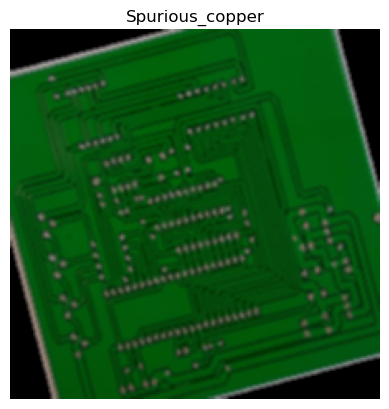

In [28]:
img , label = train_features_batch[0], train_labels_batch[0]

plt.imshow(img.permute(1,2,0))
plt.axis(False)
plt.title(class_name[label])


In [29]:
train_labels_batch[0]

tensor(5)

In [30]:
pcb_dataset.class_to_idx

{'Missing_hole': 0,
 'Mouse_bite': 1,
 'Open_circuit': 2,
 'Short': 3,
 'Spur': 4,
 'Spurious_copper': 5}

In [31]:
train_features_batch.shape

torch.Size([32, 3, 224, 224])

## Creating a Baseline Model without any Non-linearity

In [32]:
class NonLinearBaseline(nn.Module):
    def __init__(self, in_features, hidden_units, out_features) -> None:
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=in_features,
                      out_features=hidden_units),
            nn.Linear(in_features=hidden_units,
                      out_features=out_features)
        )

    
    def forward(self, X):
        return self.layer_stack(X)

In [33]:
model_0 = NonLinearBaseline(in_features=3*224*224,
                            hidden_units=50,
                            out_features=len(pcb_dataset.classes)).to(device=device)

model_0

NonLinearBaseline(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=50, bias=True)
    (2): Linear(in_features=50, out_features=6, bias=True)
  )
)

In [34]:
loss_fn = CrossEntropyLoss()
optimizer = SGD(params=model_0.parameters(),
                lr=0.01)

In [35]:
from timeit import default_timer as timer

def print_train_time(start, end, device):
    total_time = end-start
    print(f"Train time on {device}: {total_time}.2f")

In [36]:
from tqdm.auto import tqdm

e:\anaconda3\envs\Pytorch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [37]:
epochs = 10

train_time_on_gpu = timer()

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----------")
    train_loss = 0.0

    model_0.train()

    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model_0(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    train_loss /= len(train_dataloader)

    print(f"Train loss: {train_loss:.4f}")

train_time_on_gpu = timer() - train_time_on_gpu
print(f"Training time on GPU: {train_time_on_gpu:.2f} seconds")


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
-----------


 10%|█         | 1/10 [01:01<09:16, 61.87s/it]

Train loss: 3.9860
Epoch: 1
-----------


 20%|██        | 2/10 [02:07<08:30, 63.79s/it]

...

Train loss: 1.8322
Epoch: 8
-----------


 90%|█████████ | 9/10 [09:09<01:00, 60.88s/it]

Train loss: 1.8305
Epoch: 9
-----------


100%|██████████| 10/10 [10:16<00:00, 61.69s/it]

Train loss: 1.8248
Training time on GPU: 616.89 seconds
